In [1]:
import os
import sys
import yaml
import importlib
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, os.path.abspath('.'))
import graph
importlib.reload(graph)

from graph import loadPMF, iterGroupedConstructions, graphFullPairPanel

pmfPathTemp = "data/<pair>/pmf-<method>.dat"
diffPathTemp = "data/<pair>/diff-<method>.dat"
ymlPathTemp = "data/<pair>/about.yml"

saveDir = "/Users/yasmene/rc/gbx-graphs-git/figs"  # Set to a directory later when ready to save PDFs.

Loaded: data/ace-ace/pmf-gb.dat
Loaded: data/ace-ace/pmf-mm.dat
Loaded: data/ace-ace/diff-gbx.dat
Loaded: data/ace-ca/pmf-gb.dat
Loaded: data/ace-ca/pmf-mm.dat
Loaded: data/ace-ca/pmf-dft.dat
Loaded: data/ace-ca/diff-gbx.dat
Loaded: data/ace-ca/diff-gbxx.dat
Loaded: data/ace-ca/diff-mmx.dat
Loaded: data/ace-cl/pmf-gb.dat
Loaded: data/ace-cl/pmf-mm.dat
Loaded: data/ace-cl/diff-gbx.dat
Loaded: data/ace-dma/pmf-gb.dat
Loaded: data/ace-dma/pmf-mm.dat
Loaded: data/ace-dma/diff-gbx.dat
Loaded: data/ace-na/pmf-gb.dat
Loaded: data/ace-na/pmf-mm.dat
Loaded: data/ace-na/pmf-dft.dat
Loaded: data/ace-na/diff-gbx.dat
Loaded: data/ace-na/diff-gbxx.dat
Loaded: data/ace-na/diff-mmx.dat
Loaded: data/ca-ca/pmf-gb.dat
Loaded: data/ca-ca/pmf-mm.dat
Loaded: data/ca-ca/pmf-dft.dat
Loaded: data/ca-ca/diff-gbx.dat
Loaded: data/ca-ca/diff-gbxx.dat
Loaded: data/ca-ca/diff-mmx.dat
Loaded: data/ca-cl/pmf-gb.dat
Loaded: data/ca-cl/pmf-mm.dat
Loaded: data/ca-cl/pmf-dft.dat
Loaded: data/ca-cl/diff-gbx.dat
Loaded: da

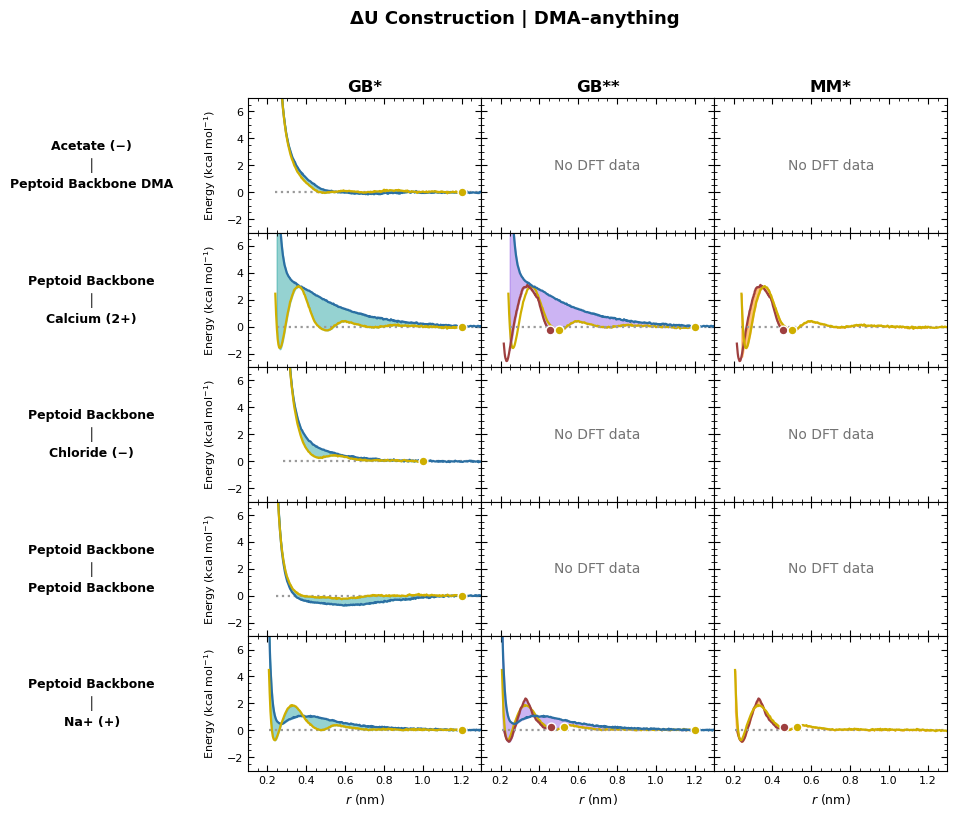

type acetate–anything


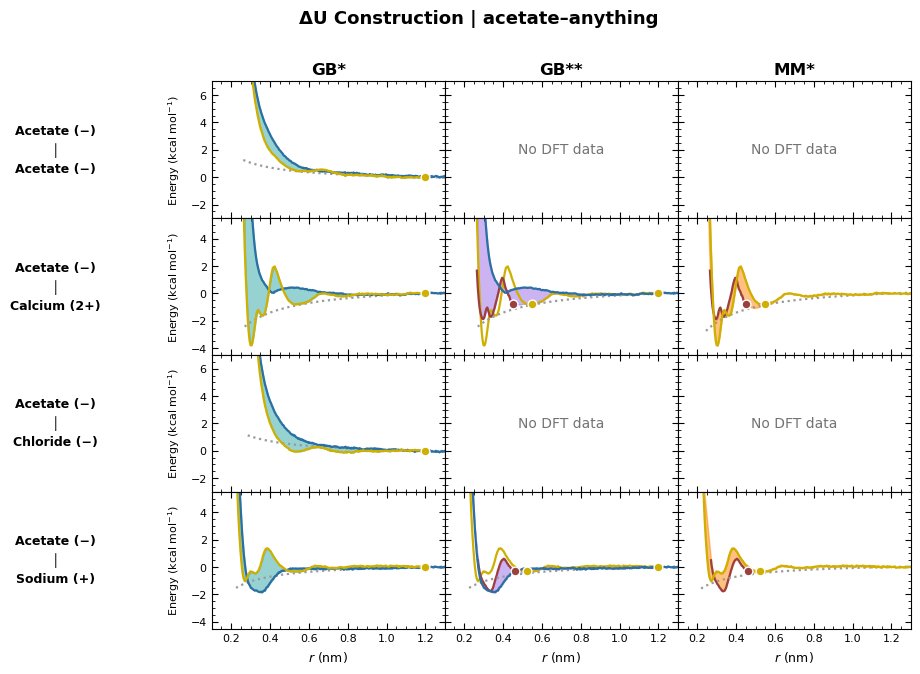

type ion–ion


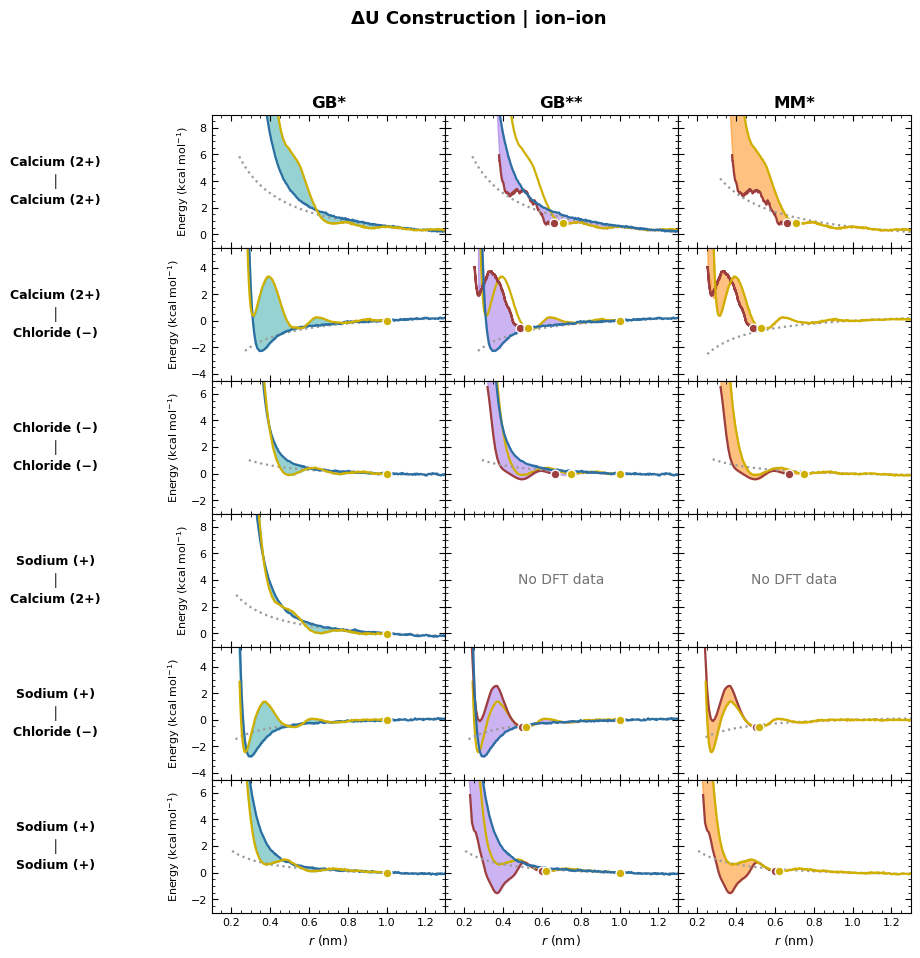

qprod -2


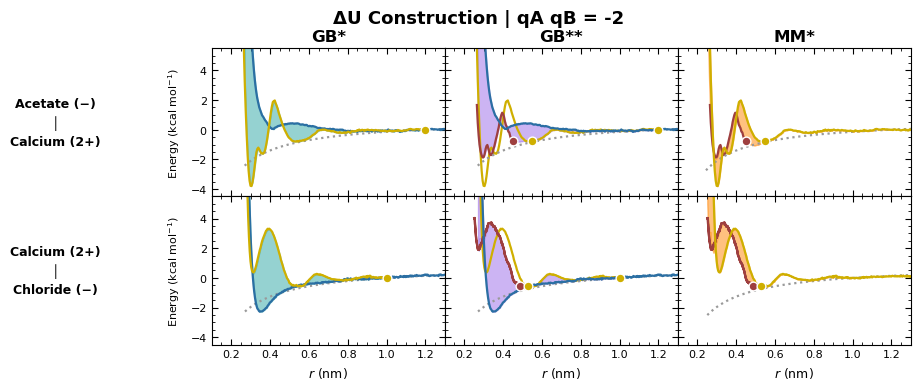

qprod -1


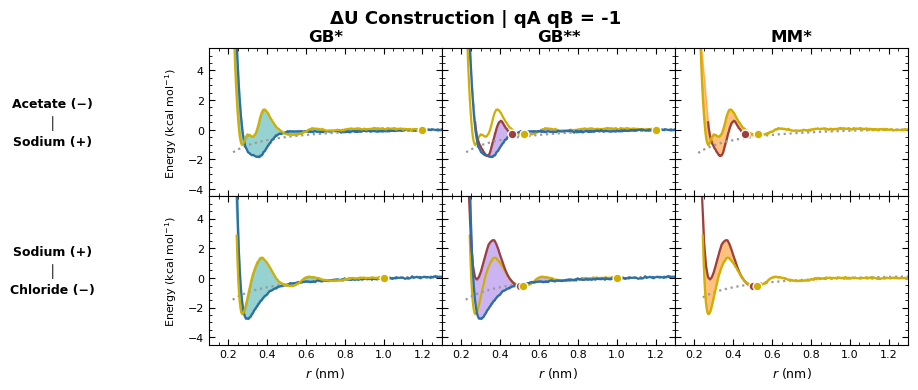

qprod 0


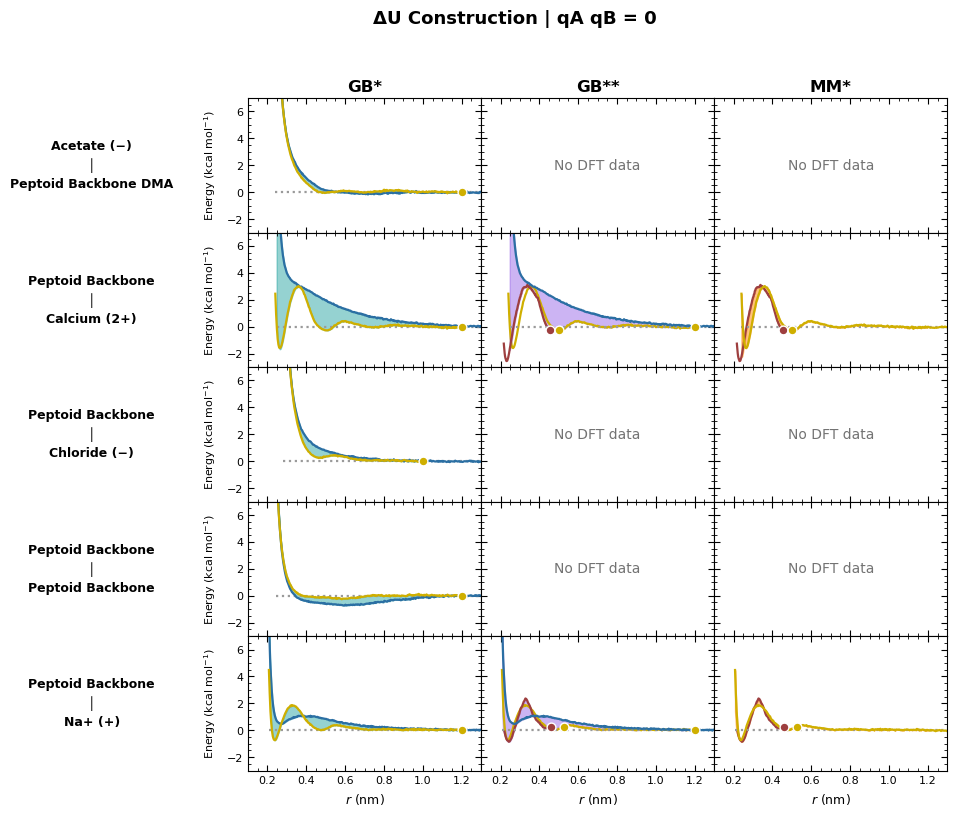

qprod 1


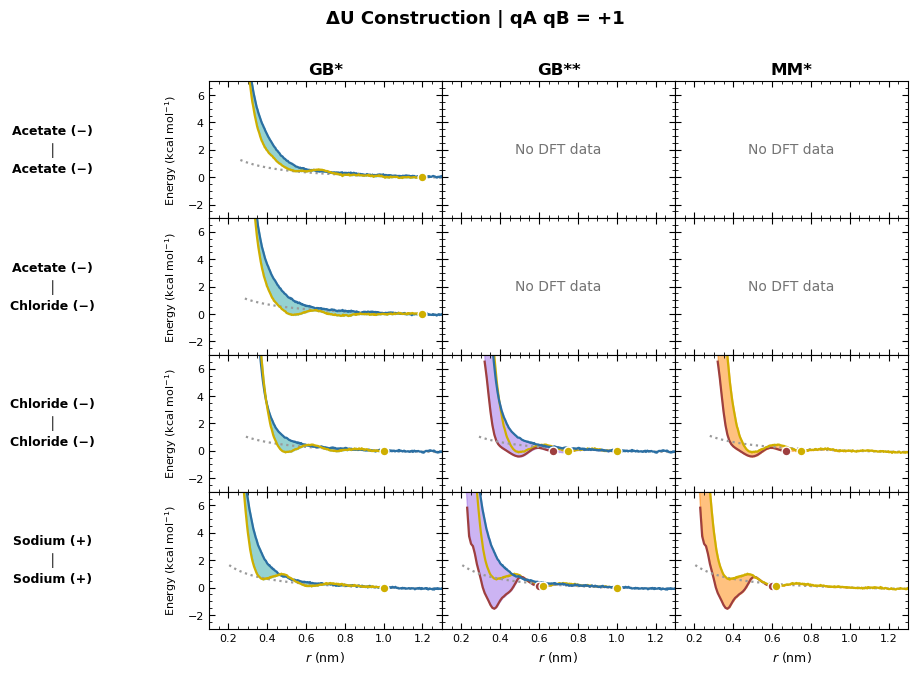

qprod 2


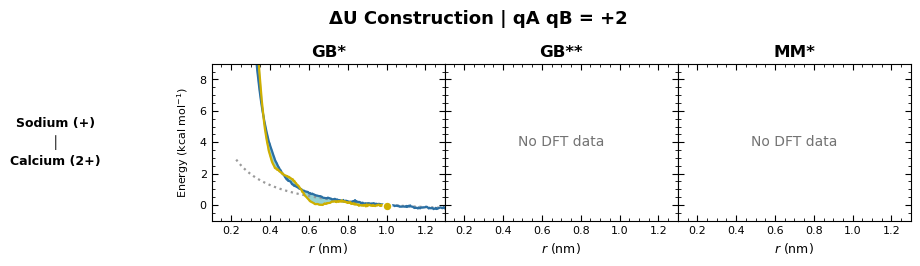

qprod 4


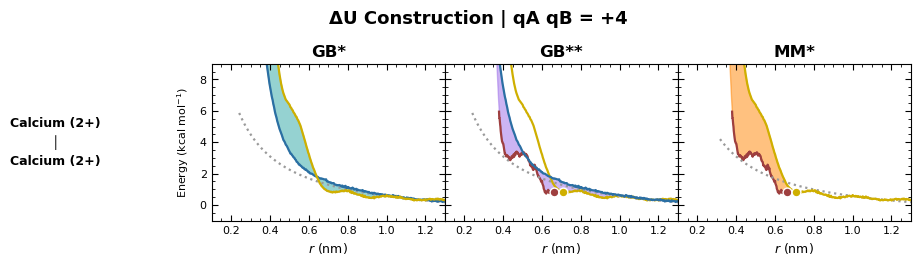

In [2]:
def temp2path(template, pair, method):
    return (
        template
        .replace('<pair>', pair)
        .replace('<method>', method)
    )

pairList = sorted(
    name for name in os.listdir('data')
    if "-" in name and os.path.isdir(os.path.join('data', name))
)

pairInfos = []

for pairName in pairList:
    ymlPath = temp2path(ymlPathTemp, pairName, '')

    if not os.path.isfile(ymlPath):
        print(f"Skipping {pairName}: no about.yml")
        continue

    with open(ymlPath) as stream:
        pairInfo = yaml.safe_load(stream)

    # Convert absent method entries to dictionaries.
    for method in ('gb', 'mm', 'dft', 'gbx', 'gbxx', 'mmx'):
        pairInfo[method] = pairInfo.get(method) or {}

    # Load available base/reference PMFs.
    for method in ('gb', 'mm', 'dft'):
        path = temp2path(pmfPathTemp, pairName, method)
        if os.path.isfile(path):
            pairInfo[method]['pmfData'] = loadPMF(path)

    # Load available corrections.
    for method in ('gbx', 'gbxx', 'mmx'):
        path = temp2path(diffPathTemp, pairName, method)
        if os.path.isfile(path) and pairInfo[method]:
            pairInfo[method]['diffData'] = loadPMF(path)

    pairInfos.append(pairInfo)

print(f"\nLoaded {len(pairInfos)} pairs")

for grouping, groupName, fig, axes in iterGroupedConstructions(pairInfos):
    print(grouping, groupName)

    # Use a filesystem-safe name for groups such as "DMA–anything".
    safeName = str(groupName).replace('–', '-').replace(' ', '_')
    savePath = os.path.join(saveDir, f"construction_{grouping}_{safeName}.pdf")
    fig.savefig(savePath, bbox_inches='tight')

    display(fig)
    plt.close(fig)

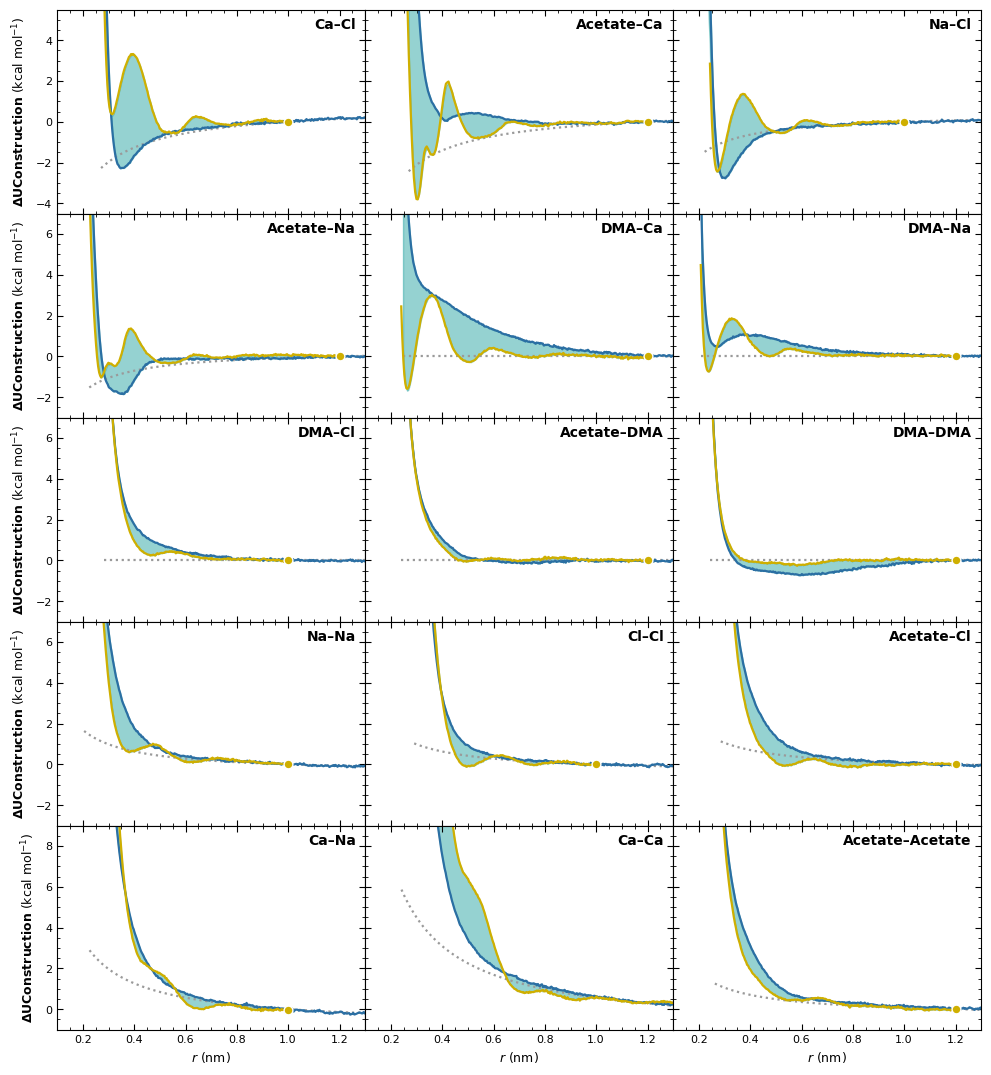

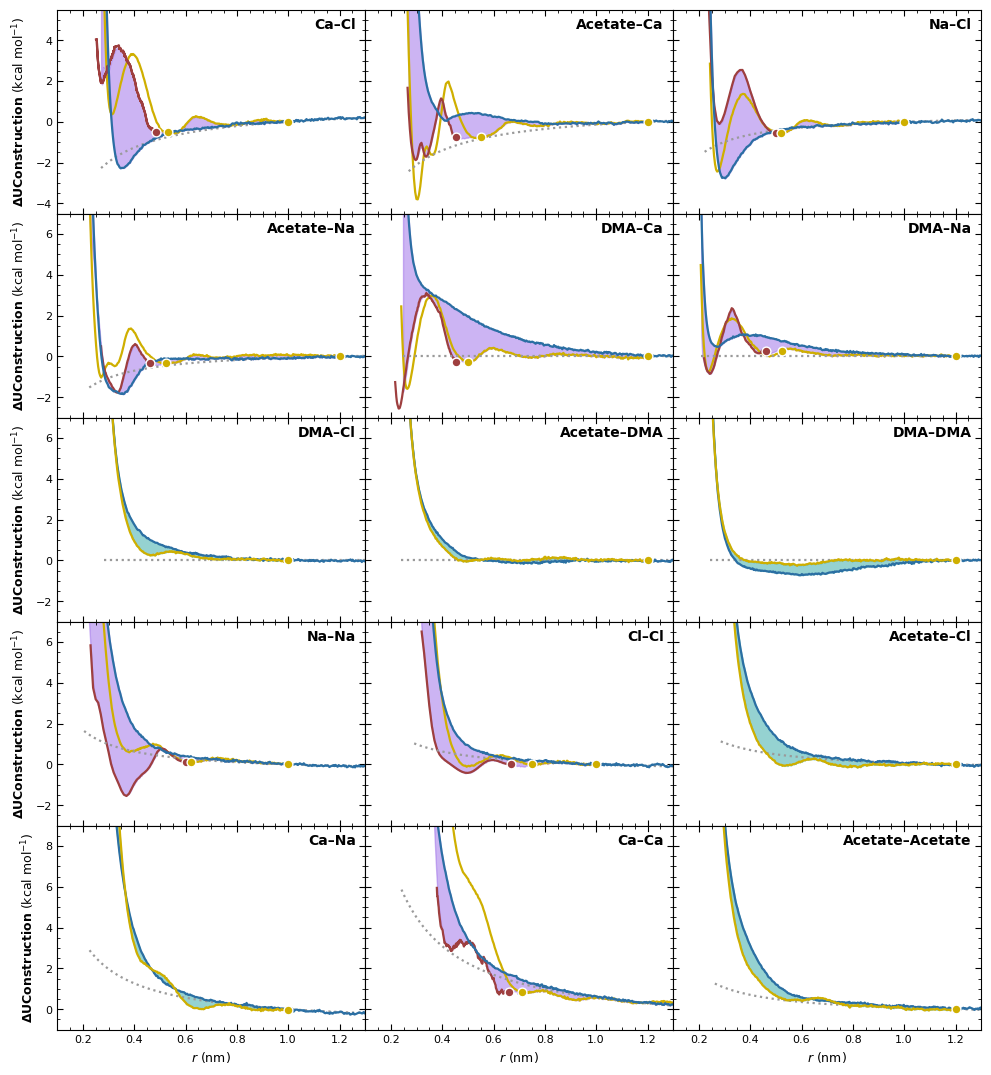

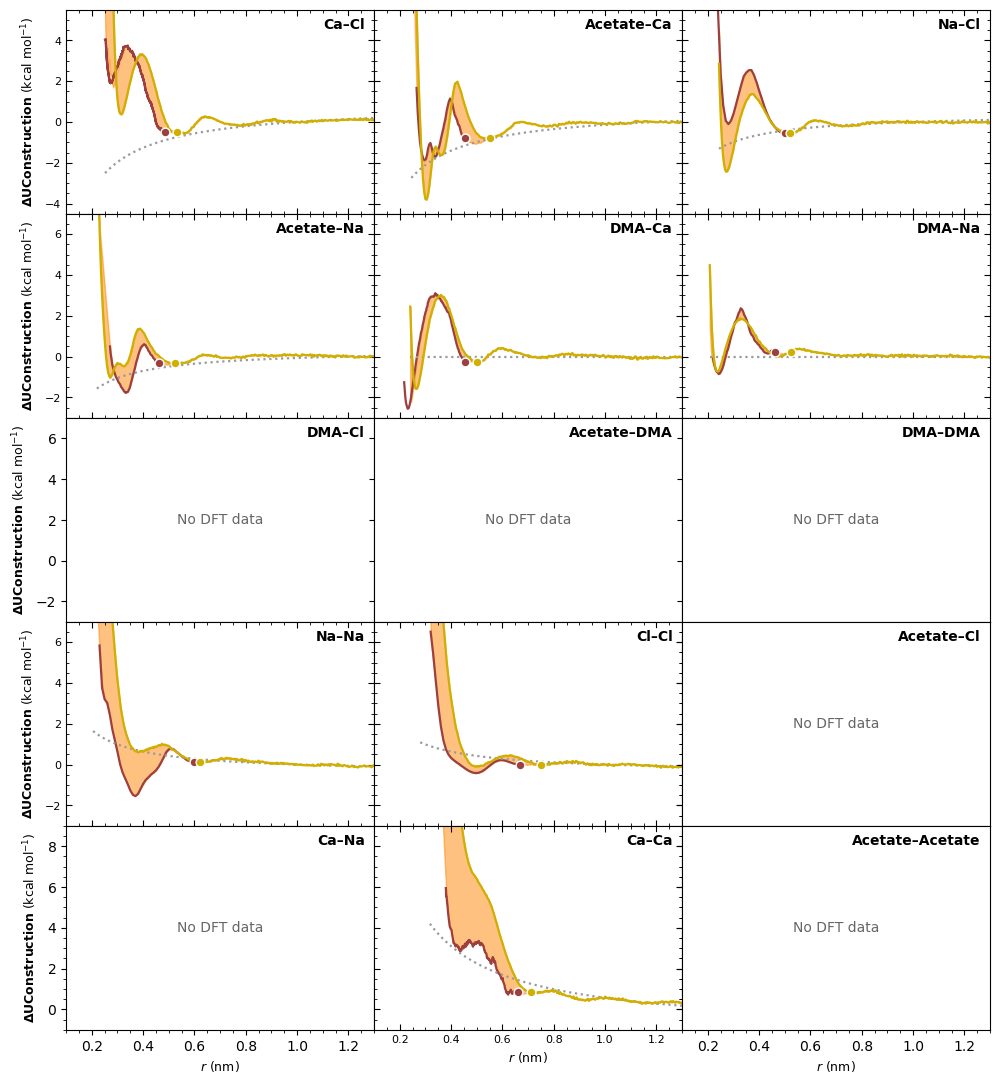

In [3]:
layout = [
    [('ca', 'cl'),  ('ace', 'ca'),  ('na', 'cl')],
    [('ace', 'na'), ('dma', 'ca'),  ('dma', 'na')],
    [('dma', 'cl'), ('ace', 'dma'), ('dma', 'dma')],
    [('na', 'na'),  ('cl', 'cl'),   ('ace', 'cl')],
    [('ca', 'na'),  ('ca', 'ca'),   ('ace', 'ace')],
]

rowYlims = [
    (-4.5, 5.5),
    (-3, 7),
    (-3, 7),
    (-3, 7),
    (-1, 9),
]

for model in ('gbx', 'gbxx', 'mmx'):
    fig, axes = graph.graphCorrectionGrid(
        pairInfos,
        layout,
        model=model,
        rowYlims=rowYlims,
    )

    savePath = os.path.join(saveDir, f"correction_grid_{model}.pdf")
    fig.savefig(savePath, bbox_inches='tight')

    display(fig)
    plt.close(fig)

Saved /Users/yasmene/rc/gbx-graphs-git/figs/representative_corrections_gbx.pdf


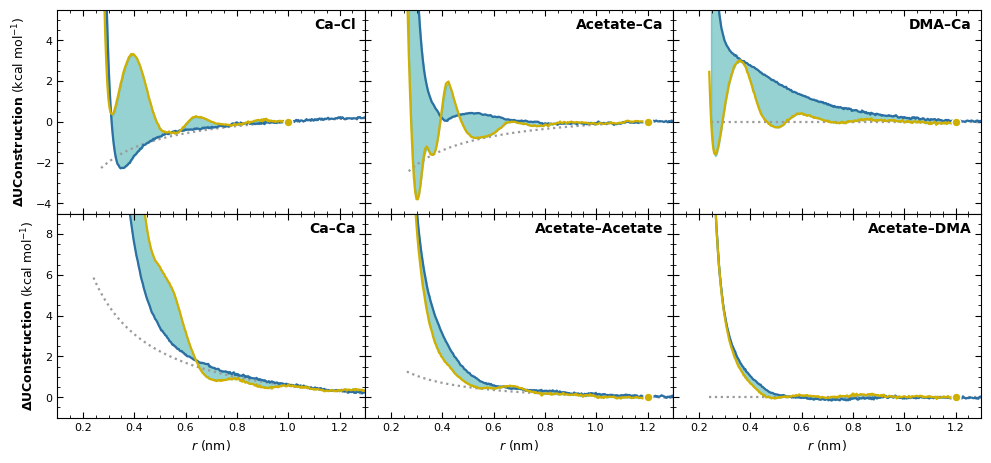

Saved /Users/yasmene/rc/gbx-graphs-git/figs/representative_corrections_gbxx.pdf


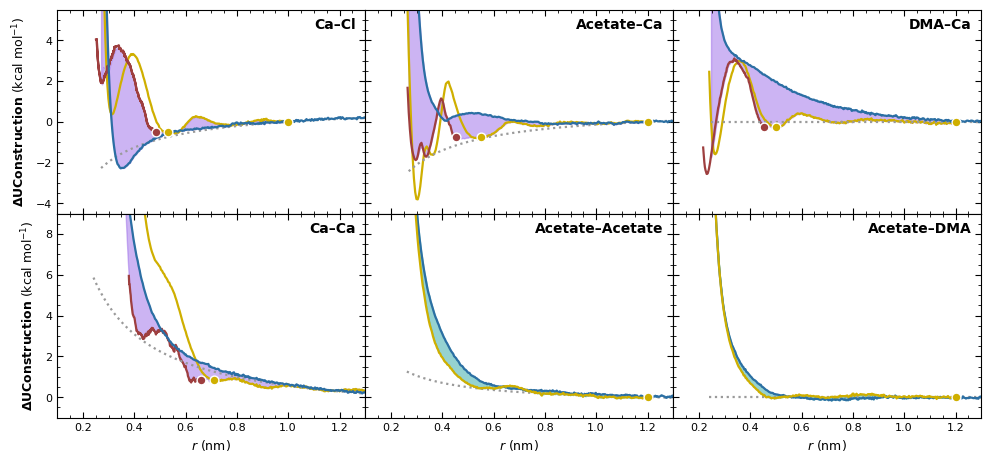

Saved /Users/yasmene/rc/gbx-graphs-git/figs/representative_corrections_mmx.pdf


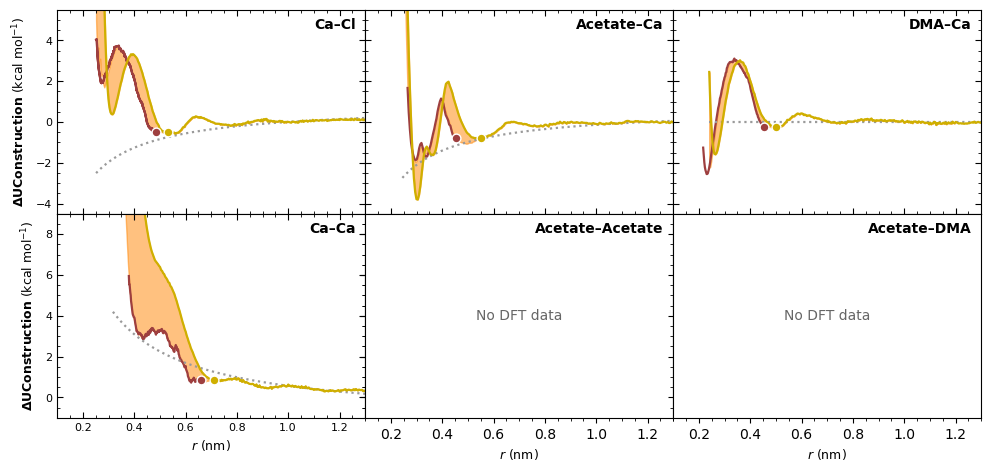

In [4]:
representativeLayout = [
    [('ca', 'cl'), ('ace', 'ca'),  ('dma', 'ca')],
    [('ca', 'ca'), ('ace', 'ace'), ('ace', 'dma')],
]

representativeYlims = [
    (-4.5, 5.5),
    (-1, 9),
]

os.makedirs(saveDir, exist_ok=True)

for model in ('gbx', 'gbxx', 'mmx'):
    fig, axes = graph.graphCorrectionGrid(
        pairInfos,
        representativeLayout,
        model=model,
        rowYlims=representativeYlims,
    )

    savePath = os.path.join(
        saveDir,
        f"representative_corrections_{model}.pdf",
    )
    fig.savefig(savePath, bbox_inches='tight')
    print(f"Saved {savePath}")

    display(fig)
    plt.close(fig)